<a href="https://colab.research.google.com/github/mhabibier/Practical-Statistics-for-Data-Scientists/blob/main/04_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Regression and Prediction

Notebook ini membahas penggunaan regresi untuk menjelaskan hubungan
antarvariabel dan melakukan prediksi.

Materi utama:

1. Simple Linear Regression
2. Multiple Linear Regression
3. Evaluasi dan validasi model
4. Model selection
5. Weighted regression
6. Prediction interval
7. Factor variables
8. Multicollinearity dan confounding
9. Regression diagnostics
10. Polynomial regression, spline, dan GAM

**Nama:** Muhammad Habibie Rabbani
**Repositori:** Practical Statistics for Data Scientists  
**Dataset:** LungDisease.csv dan house_sales.csv

## Tujuan Pembelajaran

Setelah menyelesaikan chapter ini, pembaca diharapkan dapat:

1. Menjelaskan persamaan regresi linear sederhana dan berganda.
2. Menghitung fitted value dan residual.
3. Mengevaluasi model menggunakan RMSE, MAE, dan R².
4. Menggunakan cross-validation untuk mengukur performa prediksi.
5. Menangani variabel kategorikal dalam regresi.
6. Mengenali multicollinearity, confounding, outlier, dan influential value.
7. Menggunakan confidence interval dan prediction interval.
8. Memodelkan hubungan non-linear menggunakan polynomial, spline, dan GAM.
9. Membedakan tujuan explanation dan prediction.

In [1]:
%pip install -q pandas numpy scipy scikit-learn statsmodels matplotlib seaborn dmba pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.6 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import (
    OLSInfluence,
    variance_inflation_factor,
)

from dmba import AIC_score, stepwise_selection
from pygam import LinearGAM, l, s

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42

Colab environment detected.


In [3]:
base_directory = Path("/content") if Path("/content").exists() else Path("/tmp")
source_repository = base_directory / "practical-statistics-for-data-scientists"

if not source_repository.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/gedeck/practical-statistics-for-data-scientists.git",
            str(source_repository),
        ],
        check=True,
    )

data_directory = source_repository / "data"

source_commit = subprocess.check_output(
    ["git", "-C", str(source_repository), "rev-parse", "HEAD"],
    text=True,
).strip()

print("Folder data :", data_directory)
print("Commit data :", source_commit)

Folder data : /content/practical-statistics-for-data-scientists/data
Commit data : 8a6d3bb6468e979c861d4b37215e1413702dfdfa


## 1. Persiapan dan Pemeriksaan Data

Chapter ini menggunakan dua dataset:

- `LungDisease.csv` untuk regresi linear sederhana.
- `house_sales.csv` untuk regresi berganda dan diagnosis model.

In [4]:
lung = pd.read_csv(data_directory / "LungDisease.csv")
house = pd.read_csv(data_directory / "house_sales.csv", sep="\t")

print("LungDisease :", lung.shape)
print("House sales :", house.shape)

display(lung.head())
display(house.head())

LungDisease : (122, 2)
House sales : (22687, 22)


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.9308,"300,805.0000",2,9373,2400,0,3.0000,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.9292,"1,076,162.0000",1,20156,3764,1452,3.7500,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.9779,"761,805.0000",1,26036,2060,900,1.7500,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.9614,"442,065.0000",1,8618,3200,1640,3.7500,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.8079,"297,065.0000",1,8620,1720,0,1.7500,4,7,1948,0,0,104000,205000,98168,False


In [5]:
required_lung_columns = {"PEFR", "Exposure"}

required_house_columns = {
    "AdjSalePrice",
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
    "PropertyType",
    "NbrLivingUnits",
    "SqFtFinBasement",
    "YrBuilt",
    "YrRenovated",
    "NewConstruction",
    "DocumentDate",
    "ZipCode",
}

assert required_lung_columns.issubset(lung.columns)
assert required_house_columns.issubset(house.columns)

assert lung[list(required_lung_columns)].isna().sum().sum() == 0
assert house[list(required_house_columns)].isna().sum().sum() == 0

print("Validasi schema dan missing value berhasil.")

Validasi schema dan missing value berhasil.


In [6]:
display(lung.describe().T)

display(
    house[
        [
            "AdjSalePrice",
            "SqFtTotLiving",
            "SqFtLot",
            "Bathrooms",
            "Bedrooms",
            "BldgGrade",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
PEFR,122.0000,365.6557,105.1326,110.0000,300.0000,365.0000,430.0000,610.0000
Exposure,122.0000,14.0820,6.9598,0.0000,7.0000,17.0000,20.0000,23.0000


,count,mean,std,min,25%,50%,75%,max
AdjSalePrice,"22,687.0000","565,233.2706","385,402.8600","3,368.0000","360,563.0000","471,315.0000","649,411.0000","11,644,855.0000"
SqFtTotLiving,"22,687.0000","2,080.1657",913.7422,370.0000,"1,420.0000","1,910.0000","2,540.0000","10,740.0000"
SqFtLot,"22,687.0000","11,746.3334","29,016.0202",494.0000,"4,800.0000","7,200.0000","9,794.0000","1,024,068.0000"
Bathrooms,"22,687.0000",2.1765,0.7680,0.0000,1.7500,2.2500,2.5000,8.0000
Bedrooms,"22,687.0000",3.3677,0.9044,0.0000,3.0000,3.0000,4.0000,33.0000
BldgGrade,"22,687.0000",7.6810,1.1805,3.0000,7.0000,7.0000,8.0000,13.0000


## 2. Simple Linear Regression

Regresi linear sederhana memodelkan hubungan antara satu variabel prediktor
dan satu variabel target.

\[
\hat{Y} = b_0 + b_1X
\]

Keterangan:

- \(\hat{Y}\): nilai target yang diprediksi.
- \(b_0\): intercept.
- \(b_1\): koefisien atau slope.
- \(X\): nilai prediktor.

Pada dataset LungDisease:

- `Exposure` menjadi prediktor.
- `PEFR` menjadi target.

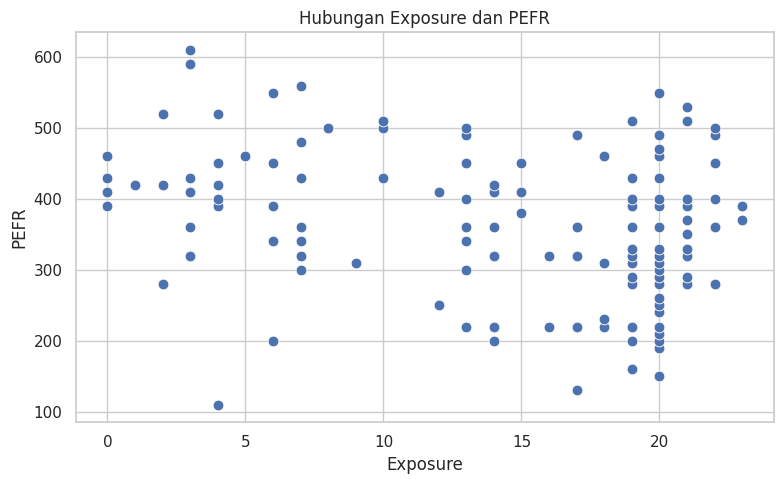

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=lung, x="Exposure", y="PEFR", s=60)
plt.title("Hubungan Exposure dan PEFR")
plt.xlabel("Exposure")
plt.ylabel("PEFR")
plt.tight_layout()
plt.show()

In [8]:
X_lung = lung[["Exposure"]]
y_lung = lung["PEFR"]

simple_model = LinearRegression()
simple_model.fit(X_lung, y_lung)

simple_prediction = simple_model.predict(X_lung)

simple_result = pd.Series(
    {
        "Intercept": simple_model.intercept_,
        "Koefisien Exposure": simple_model.coef_[0],
        "RMSE": np.sqrt(mean_squared_error(y_lung, simple_prediction)),
        "MAE": mean_absolute_error(y_lung, simple_prediction),
        "R-squared": r2_score(y_lung, simple_prediction),
        "Correlation": lung["Exposure"].corr(lung["PEFR"]),
    }
)

display(simple_result.to_frame("Nilai"))

,Nilai
Intercept,424.5828
Koefisien Exposure,-4.1846
RMSE,100.6033
MAE,80.6035
R-squared,0.0767
Correlation,-0.2770


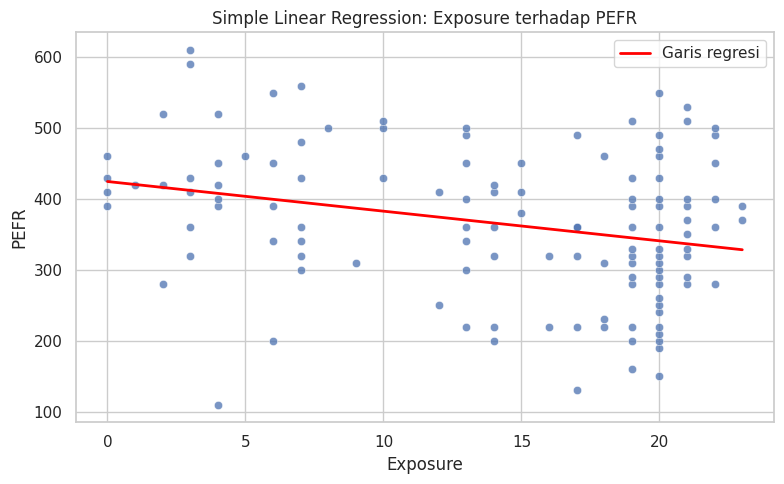

In [9]:
exposure_grid = pd.DataFrame(
    {
        "Exposure": np.linspace(
            lung["Exposure"].min(),
            lung["Exposure"].max(),
            100,
        )
    }
)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=lung, x="Exposure", y="PEFR", alpha=0.75)
plt.plot(
    exposure_grid["Exposure"],
    simple_model.predict(exposure_grid),
    color="red",
    linewidth=2,
    label="Garis regresi",
)
plt.title("Simple Linear Regression: Exposure terhadap PEFR")
plt.legend()
plt.tight_layout()
plt.show()

Model menghasilkan persamaan sekitar:

\[
\widehat{PEFR} = 424.583 - 4.185(Exposure)
\]

Koefisien negatif menunjukkan bahwa kenaikan satu unit `Exposure`
berhubungan dengan penurunan PEFR rata-rata sekitar 4,185 unit.

Nilai R² sekitar 0,077 menunjukkan bahwa model hanya menjelaskan sekitar
7,7% variasi PEFR. Dengan demikian, `Exposure` memiliki hubungan negatif,
tetapi belum cukup untuk menjelaskan seluruh variasi PEFR.

Hasil ini menunjukkan hubungan statistik, bukan bukti hubungan sebab-akibat.

### Fitted Value dan Residual

Fitted value merupakan nilai yang diprediksi oleh model:

\[
\hat{y}_i = b_0 + b_1x_i
\]

Residual merupakan selisih antara nilai aktual dan nilai prediksi:

\[
e_i = y_i - \hat{y}_i
\]

Model yang baik umumnya memiliki residual yang tersebar acak di sekitar nol.

In [10]:
lung_result = lung.copy()
lung_result["Fitted"] = simple_prediction
lung_result["Residual"] = lung_result["PEFR"] - lung_result["Fitted"]

display(lung_result.head(10))

,PEFR,Exposure,Fitted,Residual
0,390,0,424.5828,-34.5828
1,410,0,424.5828,-14.5828
2,430,0,424.5828,5.4172
3,460,0,424.5828,35.4172
4,420,1,420.3982,-0.3982
5,280,2,416.2137,-136.2137
6,420,2,416.2137,3.7863
7,520,2,416.2137,103.7863
8,610,3,412.0291,197.9709
9,590,3,412.0291,177.9709


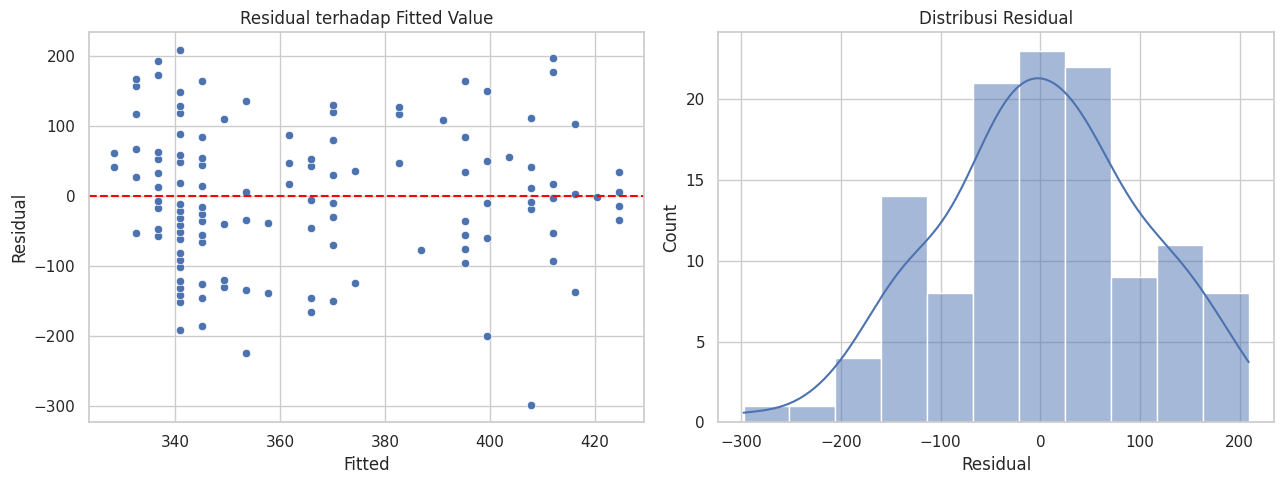

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=lung_result,
    x="Fitted",
    y="Residual",
    ax=axes[0],
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residual terhadap Fitted Value")

sns.histplot(
    data=lung_result,
    x="Residual",
    kde=True,
    ax=axes[1],
)
axes[1].set_title("Distribusi Residual")

plt.tight_layout()
plt.show()

## 3. Multiple Linear Regression

Regresi linear berganda menggunakan lebih dari satu prediktor:

\[
\hat{Y}
=
b_0+b_1X_1+b_2X_2+\cdots+b_pX_p
\]

Setiap koefisien mengukur perubahan target ketika prediktor tersebut naik
satu unit, dengan prediktor lain dianggap tetap.

In [12]:
outcome = "AdjSalePrice"

basic_predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
]

X_basic = house[basic_predictors]
y_house = house[outcome]

house_model = LinearRegression()
house_model.fit(X_basic, y_house)

house_prediction = house_model.predict(X_basic)

coefficient_table = pd.DataFrame(
    {
        "Predictor": basic_predictors,
        "Coefficient": house_model.coef_,
    }
)

display(coefficient_table)
print(f"Intercept: {house_model.intercept_:,.4f}")

,Predictor,Coefficient
0,SqFtTotLiving,228.8306
1,SqFtLot,-0.0605
2,Bathrooms,"-19,442.8404"
3,Bedrooms,"-47,769.9552"
4,BldgGrade,"106,106.9631"


Intercept: -521,871.3682


In [13]:
basic_metrics = pd.Series(
    {
        "RMSE": np.sqrt(mean_squared_error(y_house, house_prediction)),
        "MAE": mean_absolute_error(y_house, house_prediction),
        "R-squared": r2_score(y_house, house_prediction),
    }
)

display(basic_metrics.to_frame("Nilai"))

,Nilai
RMSE,"261,220.1974"
MAE,"150,660.9141"
R-squared,0.5406


Model menjelaskan sekitar 54,1% variasi harga rumah yang telah disesuaikan.
RMSE lebih besar daripada MAE karena RMSE memberikan penalti lebih tinggi
kepada residual yang sangat besar.

Koefisien tidak boleh langsung dibandingkan untuk menentukan prediktor
paling penting karena setiap prediktor menggunakan satuan yang berbeda.

In [14]:
X_basic_sm = sm.add_constant(X_basic)

ols_basic = sm.OLS(y_house, X_basic_sm).fit()

print(ols_basic.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:28   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -5.219e+05   1.57e+04    -33.342

## 4. Cross-Validation

Nilai RMSE dari data pelatihan cenderung terlalu optimistis.
Cross-validation membagi data menjadi beberapa fold agar model diuji pada
observasi yang tidak digunakan ketika melatih fold tersebut.

In [15]:
cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rmse = -cross_val_score(
    LinearRegression(),
    X_basic,
    y_house,
    cv=cross_validation,
    scoring="neg_root_mean_squared_error",
)

cv_r2 = cross_val_score(
    LinearRegression(),
    X_basic,
    y_house,
    cv=cross_validation,
    scoring="r2",
)

cv_result = pd.DataFrame(
    {
        "Fold": np.arange(1, 6),
        "RMSE": cv_rmse,
        "R-squared": cv_r2,
    }
)

display(cv_result)

print(f"Mean CV RMSE : {cv_rmse.mean():,.4f}")
print(f"Std CV RMSE  : {cv_rmse.std():,.4f}")
print(f"Mean CV R²   : {cv_r2.mean():,.4f}")

,Fold,RMSE,R-squared
0,1,"272,593.8211",0.5459
1,2,"288,085.1259",0.4939
2,3,"242,633.6067",0.5625
3,4,"231,706.0761",0.5618
4,5,"268,491.0290",0.5429


Mean CV RMSE : 260,701.9318
Std CV RMSE  : 20,587.1339
Mean CV R²   : 0.5414


## 5. Model Selection

Menambah prediktor dapat memperbaiki kecocokan model, tetapi juga dapat
meningkatkan kompleksitas dan risiko overfitting.

Model berikut menambahkan informasi tahun pembangunan, renovasi, tipe
properti, basement, unit hunian, dan status konstruksi baru.

In [16]:
full_predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
    "PropertyType",
    "NbrLivingUnits",
    "SqFtFinBasement",
    "YrBuilt",
    "YrRenovated",
    "NewConstruction",
]

X_full = pd.get_dummies(
    house[full_predictors],
    columns=["PropertyType"],
    drop_first=True,
    dtype=int,
)

full_model = LinearRegression()
full_model.fit(X_full, y_house)

full_prediction = full_model.predict(X_full)

full_metrics = pd.Series(
    {
        "Jumlah prediktor": X_full.shape[1],
        "RMSE": np.sqrt(mean_squared_error(y_house, full_prediction)),
        "MAE": mean_absolute_error(y_house, full_prediction),
        "R-squared": r2_score(y_house, full_prediction),
    }
)

display(full_metrics.to_frame("Nilai"))

,Nilai
Jumlah prediktor,12.0000
RMSE,"245,393.7759"
MAE,"136,901.4979"
R-squared,0.5946


In [17]:
def train_stepwise_model(variables):
    return LinearRegression().fit(
        X_full[list(variables)],
        y_house,
    )


def score_stepwise_model(model, variables):
    prediction = model.predict(X_full[list(variables)])
    return AIC_score(y_house, prediction, model)


selected_model, selected_variables = stepwise_selection(
    X_full.columns,
    train_stepwise_model,
    score_stepwise_model,
    verbose=False,
)

selected_variables = list(selected_variables)
selected_prediction = selected_model.predict(X_full[selected_variables])

print("Variabel terpilih:")
for variable in selected_variables:
    print("-", variable)

selected_metrics = pd.Series(
    {
        "Jumlah prediktor": len(selected_variables),
        "RMSE": np.sqrt(
            mean_squared_error(y_house, selected_prediction)
        ),
        "R-squared": r2_score(y_house, selected_prediction),
    }
)

display(selected_metrics.to_frame("Nilai"))

ValueError: at least one array or dtype is required

Stepwise selection berguna untuk eksplorasi, tetapi hasilnya dapat tidak
stabil ketika prediktor saling berkorelasi. Nilai performa dari proses
pemilihan yang dilakukan pada seluruh data juga bukan estimasi performa
out-of-sample yang tidak bias.

Untuk penggunaan produksi, proses pemilihan variabel seharusnya dilakukan
di dalam cross-validation atau nested cross-validation.

## 6. Weighted Regression

Weighted regression memberikan bobot berbeda kepada setiap observasi.
Pada contoh ini, transaksi yang lebih baru memperoleh bobot lebih besar
karena dianggap lebih mewakili kondisi pasar terbaru.

In [ ]:
house = house.copy()
house["Year"] = pd.to_datetime(house["DocumentDate"]).dt.year
house["Weight"] = (house["Year"] - 2005).clip(lower=1)

weighted_model = LinearRegression()
weighted_model.fit(
    X_basic,
    y_house,
    sample_weight=house["Weight"],
)

weighted_prediction = weighted_model.predict(X_basic)

weighted_coefficients = pd.DataFrame(
    {
        "Predictor": basic_predictors,
        "Unweighted": house_model.coef_,
        "Weighted": weighted_model.coef_,
    }
)

display(weighted_coefficients)

In [ ]:
comparison_by_year = house[
    ["Year", "AdjSalePrice"]
].copy()

comparison_by_year["UnweightedPrediction"] = house_prediction
comparison_by_year["WeightedPrediction"] = weighted_prediction

yearly_rows = []

for year, group in comparison_by_year.groupby("Year"):
    yearly_rows.append(
        {
            "Year": year,
            "Unweighted MAE": mean_absolute_error(
                group["AdjSalePrice"],
                group["UnweightedPrediction"],
            ),
            "Weighted MAE": mean_absolute_error(
                group["AdjSalePrice"],
                group["WeightedPrediction"],
            ),
        }
    )

yearly_error = pd.DataFrame(yearly_rows)
display(yearly_error)

In [ ]:
yearly_error.plot(
    x="Year",
    y=["Unweighted MAE", "Weighted MAE"],
    marker="o",
    figsize=(10, 5),
)

plt.ylabel("MAE")
plt.title("Perbandingan Error Berdasarkan Tahun")
plt.tight_layout()
plt.show()

## 7. Prediction Using Regression

Dua interval yang perlu dibedakan:

| Interval | Menjawab pertanyaan |
|---|---|
| Confidence interval | Di mana rata-rata target untuk kombinasi prediktor tertentu berada? |
| Prediction interval | Di mana satu observasi baru kemungkinan berada? |

Prediction interval lebih lebar karena memasukkan ketidakpastian model
dan variasi individual observasi.

In [ ]:
new_houses = X_basic.iloc[:3].copy()

new_houses_sm = sm.add_constant(
    new_houses,
    has_constant="add",
)

prediction_interval = ols_basic.get_prediction(
    new_houses_sm
).summary_frame(alpha=0.05)

prediction_result = pd.concat(
    [
        new_houses.reset_index(drop=True),
        y_house.iloc[:3].reset_index(drop=True).rename("Actual"),
        prediction_interval.reset_index(drop=True),
    ],
    axis=1,
)

display(prediction_result)

Regresi sebaiknya tidak digunakan jauh di luar rentang data training.
Prediksi di luar rentang tersebut disebut extrapolation dan dapat sangat
tidak stabil karena pola di luar data belum pernah diamati.

## 8. Factor Variables

Algoritma regresi membutuhkan input numerik. Variabel kategorikal seperti
`PropertyType` diubah menjadi dummy variables.

Jika suatu variabel memiliki \(k\) kategori, gunakan \(k-1\) dummy agar
tidak terjadi ketergantungan linear sempurna.

In [ ]:
print("Kategori PropertyType:")
print(sorted(house["PropertyType"].unique()))

X_factor = pd.get_dummies(
    house[basic_predictors + ["PropertyType"]],
    columns=["PropertyType"],
    drop_first=True,
    dtype=int,
)

factor_model = LinearRegression()
factor_model.fit(X_factor, y_house)

factor_coefficients = pd.Series(
    factor_model.coef_,
    index=X_factor.columns,
    name="Coefficient",
).to_frame()

display(factor_coefficients)
print(f"Intercept: {factor_model.intercept_:,.4f}")

In [ ]:
house_zip = house.copy()
house_zip["BaseResidual"] = y_house - house_prediction

zip_statistics = (
    house_zip.groupby("ZipCode")
    .agg(
        MedianResidual=("BaseResidual", "median"),
        Count=("BaseResidual", "size"),
    )
    .sort_values("MedianResidual")
    .reset_index()
)

zip_statistics["CumulativeCount"] = zip_statistics["Count"].cumsum()

zip_statistics["ZipGroup"] = pd.qcut(
    zip_statistics["CumulativeCount"],
    q=5,
    labels=False,
    duplicates="drop",
)

house_zip = house_zip.merge(
    zip_statistics[["ZipCode", "ZipGroup"]],
    on="ZipCode",
    how="left",
    validate="many_to_one",
)

house_zip["ZipGroup"] = house_zip["ZipGroup"].astype("category")

display(house_zip["ZipGroup"].value_counts().sort_index())

Kelompok ZIP di atas dibentuk menggunakan residual yang berasal dari target.
Karena itu, pengelompokan tersebut berpotensi menyebabkan target leakage
jika dibuat sebelum train-test split atau sebelum cross-validation.

Contoh ini aman sebagai demonstrasi interpretasi pada data buku. Untuk
evaluasi prediksi nyata, pengelompokan harus dibuat hanya dari training
fold, kemudian diterapkan pada validation/test fold.

## 9. Correlated Predictors dan Multicollinearity

Multicollinearity terjadi ketika beberapa prediktor membawa informasi yang
sangat mirip. Kondisi ini dapat membuat koefisien tidak stabil, memperbesar
standard error, dan menyulitkan interpretasi.

In [ ]:
correlation_matrix = house[basic_predictors].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Korelasi Antar-Prediktor")
plt.tight_layout()
plt.show()

In [ ]:
vif_input = sm.add_constant(
    house[basic_predictors].astype(float)
)

vif_result = pd.DataFrame(
    {
        "Predictor": basic_predictors,
        "VIF": [
            variance_inflation_factor(vif_input.values, index)
            for index in range(1, vif_input.shape[1])
        ],
    }
)

display(vif_result.sort_values("VIF", ascending=False))

## 10. Confounding Variables

Confounding terjadi ketika variabel yang tidak dimasukkan berkaitan dengan
prediktor sekaligus target. Penambahan lokasi dapat mengubah koefisien
karakteristik bangunan karena harga rumah sangat dipengaruhi wilayah.

In [ ]:
confounding_formula = """
AdjSalePrice ~
SqFtTotLiving +
SqFtLot +
Bathrooms +
Bedrooms +
BldgGrade +
C(PropertyType) +
C(ZipGroup)
"""

confounding_model = smf.ols(
    formula=confounding_formula,
    data=house_zip,
).fit()

display(
    confounding_model.params.to_frame("Coefficient")
)

print(f"R-squared: {confounding_model.rsquared:.4f}")

## 11. Interaction Effect

Interaction berarti efek suatu prediktor berubah bergantung pada variabel
lain. Sebagai contoh, tambahan luas bangunan dapat memiliki nilai ekonomi
yang berbeda pada kelompok wilayah yang berbeda.

In [ ]:
interaction_formula = """
AdjSalePrice ~
SqFtTotLiving * C(ZipGroup) +
SqFtLot +
Bathrooms +
Bedrooms +
BldgGrade +
C(PropertyType)
"""

interaction_model = smf.ols(
    formula=interaction_formula,
    data=house_zip,
).fit()

interaction_parameters = interaction_model.params[
    interaction_model.params.index.str.contains("SqFtTotLiving")
]

display(interaction_parameters.to_frame("Coefficient"))

print(f"R-squared: {interaction_model.rsquared:.4f}")
print(f"AIC      : {interaction_model.aic:,.4f}")

## 12. Regression Diagnostics

Diagnosis regresi digunakan untuk memeriksa:

1. Outlier.
2. Influential observation.
3. Heteroskedasticity.
4. Non-normal residual.
5. Correlated errors.
6. Non-linear relationship.

In [ ]:
house_98105 = house.loc[
    house["ZipCode"] == 98105
].copy()

X_98105 = sm.add_constant(
    house_98105[basic_predictors]
)

y_98105 = house_98105["AdjSalePrice"]

ols_98105 = sm.OLS(
    y_98105,
    X_98105,
).fit()

print(f"Jumlah observasi: {len(house_98105)}")
print(f"R-squared       : {ols_98105.rsquared:.4f}")
print(f"AIC             : {ols_98105.aic:,.4f}")

In [ ]:
influence = OLSInfluence(ols_98105)

studentized_residual = pd.Series(
    influence.resid_studentized_internal,
    index=house_98105.index,
)

cooks_distance = pd.Series(
    influence.cooks_distance[0],
    index=house_98105.index,
)

diagnostic_data = house_98105[
    [
        "AdjSalePrice",
        "SqFtTotLiving",
        "SqFtLot",
        "Bathrooms",
        "Bedrooms",
        "BldgGrade",
    ]
].copy()

diagnostic_data["Fitted"] = ols_98105.fittedvalues
diagnostic_data["Residual"] = ols_98105.resid
diagnostic_data["StudentizedResidual"] = studentized_residual
diagnostic_data["CooksDistance"] = cooks_distance

largest_residual_indices = (
    diagnostic_data["StudentizedResidual"]
    .abs()
    .nlargest(5)
    .index
)

largest_cooks_indices = (
    diagnostic_data["CooksDistance"]
    .nlargest(5)
    .index
)

print("Observasi dengan studentized residual terbesar:")
display(diagnostic_data.loc[largest_residual_indices])

print("Observasi dengan Cook's distance terbesar:")
display(diagnostic_data.loc[largest_cooks_indices])

In [ ]:
relative_cooks = cooks_distance / cooks_distance.max()
point_size = 30 + 1_000 * np.sqrt(relative_cooks)

plt.figure(figsize=(10, 6))
plt.scatter(
    ols_98105.fittedvalues,
    studentized_residual,
    s=point_size,
    alpha=0.45,
)

plt.axhline(0, color="black", linestyle="--")
plt.axhline(3, color="red", linestyle=":")
plt.axhline(-3, color="red", linestyle=":")

for index in cooks_distance.nlargest(3).index:
    plt.annotate(
        str(index),
        (
            ols_98105.fittedvalues.loc[index],
            studentized_residual.loc[index],
        ),
    )

plt.xlabel("Fitted Value")
plt.ylabel("Studentized Residual")
plt.title("Residual dan Influential Observations")
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    x=ols_98105.fittedvalues,
    y=ols_98105.resid,
    ax=axes[0],
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Fitted")

sns.histplot(
    ols_98105.resid,
    kde=True,
    ax=axes[1],
)
axes[1].set_title("Distribusi Residual")

plt.tight_layout()
plt.show()

In [ ]:
sm.qqplot(
    studentized_residual,
    line="45",
    fit=True,
)

plt.title("Q-Q Plot Studentized Residual")
plt.tight_layout()
plt.show()

In [ ]:
bp_statistic, bp_pvalue, bp_fvalue, bp_f_pvalue = (
    het_breuschpagan(
        ols_98105.resid,
        ols_98105.model.exog,
    )
)

diagnostic_tests = pd.Series(
    {
        "Breusch-Pagan statistic": bp_statistic,
        "Breusch-Pagan p-value": bp_pvalue,
        "Breusch-Pagan F p-value": bp_f_pvalue,
        "Durbin-Watson": sm.stats.stattools.durbin_watson(
            ols_98105.resid
        ),
    }
)

display(diagnostic_tests.to_frame("Nilai"))

In [ ]:
figure = sm.graphics.plot_ccpr(
    ols_98105,
    "SqFtTotLiving",
)

figure.set_size_inches(9, 6)
plt.title("Partial Residual Plot: SqFtTotLiving")
plt.tight_layout()
plt.show()

## 13. Polynomial Regression

Polynomial regression menambahkan pangkat suatu prediktor:

\[
\hat{Y}
=
b_0+b_1X+b_2X^2
\]

Walaupun prediktornya memiliki pangkat, model tetap linear terhadap
koefisien \(b_0\), \(b_1\), dan \(b_2\).

In [ ]:
polynomial_formula = """
AdjSalePrice ~
SqFtTotLiving +
I(SqFtTotLiving ** 2) +
SqFtLot +
Bathrooms +
Bedrooms +
BldgGrade
"""

polynomial_model = smf.ols(
    formula=polynomial_formula,
    data=house_98105,
).fit()

print(f"R-squared: {polynomial_model.rsquared:.4f}")
print(f"AIC      : {polynomial_model.aic:,.4f}")

display(
    polynomial_model.params[
        [
            "SqFtTotLiving",
            "I(SqFtTotLiving ** 2)",
        ]
    ].to_frame("Coefficient")
)

## 14. Spline Regression

Spline membagi rentang prediktor menjadi beberapa bagian yang dihubungkan
secara halus. Metode ini lebih fleksibel daripada satu kurva polynomial
global.

In [ ]:
spline_formula = """
AdjSalePrice ~
bs(SqFtTotLiving, df=6, degree=3) +
SqFtLot +
Bathrooms +
Bedrooms +
BldgGrade
"""

spline_model = smf.ols(
    formula=spline_formula,
    data=house_98105,
).fit()

print(f"R-squared: {spline_model.rsquared:.4f}")
print(f"AIC      : {spline_model.aic:,.4f}")

## 15. Generalized Additive Model

Generalized Additive Model atau GAM menggabungkan fungsi halus dari
prediktor:

\[
Y = \beta_0 + f_1(X_1) + f_2(X_2) + \cdots + \epsilon
\]

GAM dapat menangkap hubungan non-linear sambil mempertahankan struktur
model yang masih relatif mudah diinterpretasikan.

In [ ]:
X_gam = house_98105[basic_predictors].to_numpy()
y_gam = house_98105["AdjSalePrice"].to_numpy()

gam_model = LinearGAM(
    s(0) +
    l(1) +
    l(2) +
    l(3) +
    l(4)
).gridsearch(
    X_gam,
    y_gam,
    progress=False,
)

gam_prediction = gam_model.predict(X_gam)

gam_metrics = pd.Series(
    {
        "RMSE": np.sqrt(
            mean_squared_error(y_gam, gam_prediction)
        ),
        "Explained deviance": (
            gam_model.statistics_["pseudo_r2"]["explained_deviance"]
        ),
        "AIC": gam_model.statistics_["AIC"],
    }
)

display(gam_metrics.to_frame("Nilai"))

In [ ]:
feature_names = basic_predictors

fig, axes = plt.subplots(
    1,
    len(feature_names),
    figsize=(20, 4),
)

for term_index, axis in enumerate(axes):
    grid = gam_model.generate_X_grid(term=term_index)

    axis.plot(
        grid[:, term_index],
        gam_model.partial_dependence(
            term=term_index,
            X=grid,
        ),
    )

    axis.set_title(feature_names[term_index])
    axis.set_xlabel(feature_names[term_index])
    axis.set_ylabel("Partial effect")

plt.tight_layout()
plt.show()

In [ ]:
model_comparison = pd.DataFrame(
    [
        {
            "Model": "Linear",
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_98105,
                    ols_98105.fittedvalues,
                )
            ),
            "R-squared": ols_98105.rsquared,
            "AIC": ols_98105.aic,
        },
        {
            "Model": "Polynomial",
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_98105,
                    polynomial_model.fittedvalues,
                )
            ),
            "R-squared": polynomial_model.rsquared,
            "AIC": polynomial_model.aic,
        },
        {
            "Model": "Spline",
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_98105,
                    spline_model.fittedvalues,
                )
            ),
            "R-squared": spline_model.rsquared,
            "AIC": spline_model.aic,
        },
        {
            "Model": "GAM",
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_gam,
                    gam_prediction,
                )
            ),
            "R-squared": (
                gam_model.statistics_["pseudo_r2"][
                    "explained_deviance"
                ]
            ),
            "AIC": gam_model.statistics_["AIC"],
        },
    ]
)

display(
    model_comparison.sort_values("AIC")
)

In [ ]:
living_space = np.linspace(
    house_98105["SqFtTotLiving"].quantile(0.01),
    house_98105["SqFtTotLiving"].quantile(0.99),
    200,
)

prediction_grid = pd.DataFrame(
    {
        "SqFtTotLiving": living_space,
        "SqFtLot": house_98105["SqFtLot"].median(),
        "Bathrooms": house_98105["Bathrooms"].median(),
        "Bedrooms": house_98105["Bedrooms"].median(),
        "BldgGrade": house_98105["BldgGrade"].median(),
    }
)

linear_curve = ols_98105.predict(
    sm.add_constant(
        prediction_grid[basic_predictors],
        has_constant="add",
    )
)

polynomial_curve = polynomial_model.predict(prediction_grid)
spline_curve = spline_model.predict(prediction_grid)
gam_curve = gam_model.predict(
    prediction_grid[basic_predictors].to_numpy()
)

plt.figure(figsize=(11, 7))

plt.scatter(
    house_98105["SqFtTotLiving"],
    house_98105["AdjSalePrice"],
    alpha=0.25,
    label="Observasi",
)

plt.plot(living_space, linear_curve, label="Linear")
plt.plot(living_space, polynomial_curve, label="Polynomial")
plt.plot(living_space, spline_curve, label="Spline")
plt.plot(living_space, gam_curve, label="GAM")

plt.xlabel("SqFtTotLiving")
plt.ylabel("AdjSalePrice")
plt.title("Perbandingan Bentuk Model")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Kesimpulan

Regresi dapat digunakan untuk dua tujuan utama, yaitu explanation dan
prediction. Untuk explanation, perhatian utama diberikan pada koefisien,
ketidakpastian, confounding, dan asumsi model. Untuk prediction, perhatian
utama diberikan pada kemampuan generalisasi yang diukur menggunakan data
validasi atau cross-validation.

Pada dataset rumah, model dasar menjelaskan sekitar 54% variasi harga.
Penambahan prediktor meningkatkan R² menjadi sekitar 59%, sedangkan
informasi lokasi dan interaction meningkatkan kecocokan model lebih lanjut.

Diagnosis residual menunjukkan bahwa model perlu diperiksa terhadap
outlier, influential observations, heteroskedasticity, dan hubungan
non-linear. Polynomial regression, spline, dan GAM dapat meningkatkan
fleksibilitas, tetapi model yang lebih kompleks tetap harus dinilai
menggunakan validasi out-of-sample.

Model yang memiliki R² terbesar pada data training belum tentu menjadi
model terbaik untuk data baru. Pemilihan akhir harus mempertimbangkan
akurasi, interpretabilitas, stabilitas, dan tujuan analisis.

## 18. References

1. Bruce, P., Bruce, A., & Gedeck, P. *Practical Statistics for Data Scientists*.
2. Scikit-learn Documentation — Linear Models and Model Evaluation.
3. Statsmodels Documentation — Regression and Diagnostic Statistics.
4. PyGAM Documentation — Generalized Additive Models.
5. Official code repository:
   https://github.com/gedeck/practical-statistics-for-data-scientists